# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [2]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

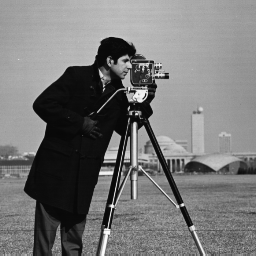

In [6]:
# ── Load image ────────────────────────────────────
img = Image.open('images/cameraman.png').convert('RGB')
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [7]:
# Get the size of the image
width, height = img.size
print('Original size:', img.size)

# scaling factors
cx, cy = 2, 2
new_size = (int(width * cx), int(height * cy))
print('New size:', new_size)

Original size: (256, 256)
New size: (512, 512)


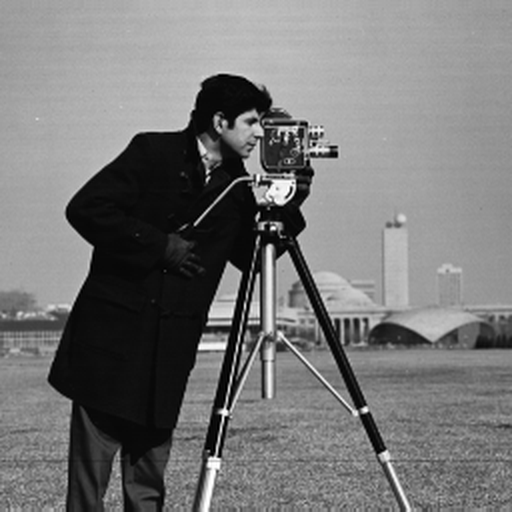

In [8]:
# ── 1. Increase size (scale ×2) ────────────────────
scaled_img = img.resize(new_size, Image.Resampling.LANCZOS)
display(scaled_img)

In [9]:
scaled_img.save('task1_1_scaled.jpg')

print('Original size:', img.size)
print('Scaled size:', scaled_img.size)

Original size: (256, 256)
Scaled size: (512, 512)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [10]:
cx, cy = 2, 1

non_uniform_size = (
    int(width * cx),
    int(height * cy)
)

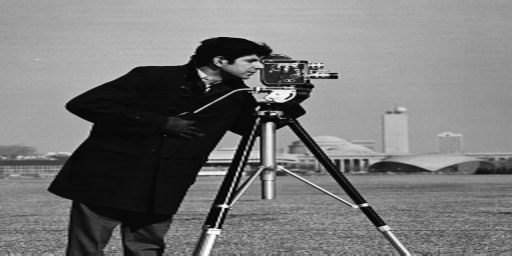

In [11]:
non_uniform_img = img.resize(
    non_uniform_size,
    Image.Resampling.LANCZOS
)

display(non_uniform_img)

In [12]:
non_uniform_img.save('task1_1_non_uniform_scaled.jpg')

print('Original size:', img.size)
print('Non-uniform scaled size:', non_uniform_img.size)

Original size: (256, 256)
Non-uniform scaled size: (512, 256)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (256, 256)
Rotated size: (350, 350)


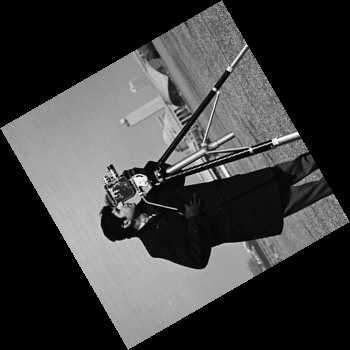

In [13]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(
    120,
    expand=True,
    resample=Image.Resampling.BICUBIC
)

rotated_img.save('task1_2_rotated.jpg')

print('Original size:', img.size)
print('Rotated size:', rotated_img.size)

display(rotated_img)

### 3. Shear

In [14]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

print('Width:', width)
print('Height:', height)

Width: 256
Height: 256


In [15]:
# -- d. define the shear matrix ──────────────────────────
shx = 0.5
shy = 0.0

new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)

print('Sheared canvas:', (new_width, new_height))

Sheared canvas: (384, 256)


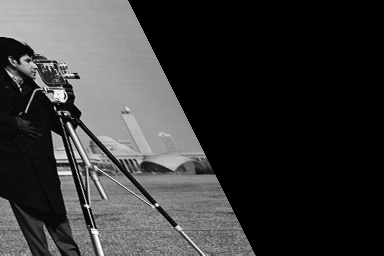

In [16]:
# -- e. Apply the shear transformation to the image ──────────────────────────
tx = abs(shx) * height if shx > 0 else 0
ty = abs(shy) * width if shy > 0 else 0

sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, tx, -shy, 1, ty),
    resample=Image.Resampling.BICUBIC
)

display(sheared_img)

In [17]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save('task1_3_sheared.jpg')

print('Sheared image saved as task1_3_sheared.jpg')

Sheared image saved as task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

Comparison:
As the shear factor increases from 0.1 to 0.8, the image becomes more distorted. X-axis shear shifts the image horizontally, while Y-axis shear shifts it vertically. Combining X and Y shear causes distortion in both directions. The canvas size was adjusted according to the shear factor to prevent cropping.

# Intensity Transformations
Negative · Log · Power Law (Gamma)

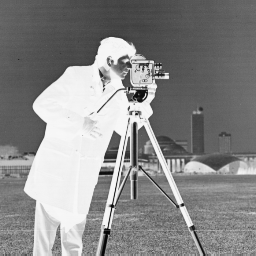

In [18]:
# ── 1. Negative ──────────────────────────────────── 
arr = np.array(img)

negative_arr = 255 - arr

negative_img = Image.fromarray(
    negative_arr.astype(np.uint8)
)

negative_img.save('task2_1_negative_numpy.jpg')

display(negative_img)

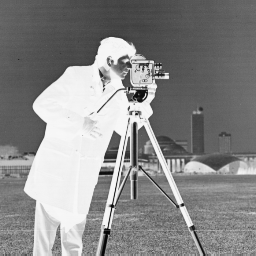

In [19]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(img)

negative_pil.save('task2_1_negative_pil.jpg')

display(negative_pil)

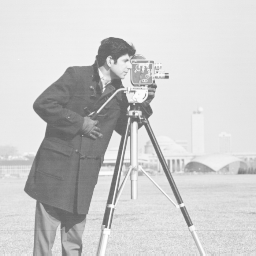

In [21]:
# ── 2. Log transformation ────────────────────────
arr = np.array(img).astype(np.float32)

c = 255 / np.log(1 + 255)

log_transformed_arr = c * np.log1p(arr)

log_transformed_arr = np.clip(
    log_transformed_arr,
    0,
    255
).astype(np.uint8)

log_transformed_img = Image.fromarray(
    log_transformed_arr
)

log_transformed_img.save('task2_2_log.jpg')

display(log_transformed_img)

Gamma = 0.5


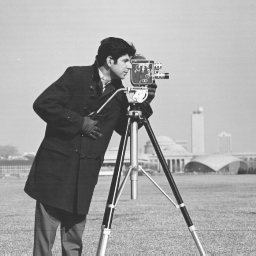

In [22]:
# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

arr = np.array(img).astype(np.float32) / 255.0

gamma_arr = 255 * np.power(arr, gamma)

gamma_img = Image.fromarray(
    np.clip(gamma_arr, 0, 255).astype(np.uint8)
)

gamma_img.save('task2_3_gamma.jpg')

print('Gamma =', gamma)

display(gamma_img)

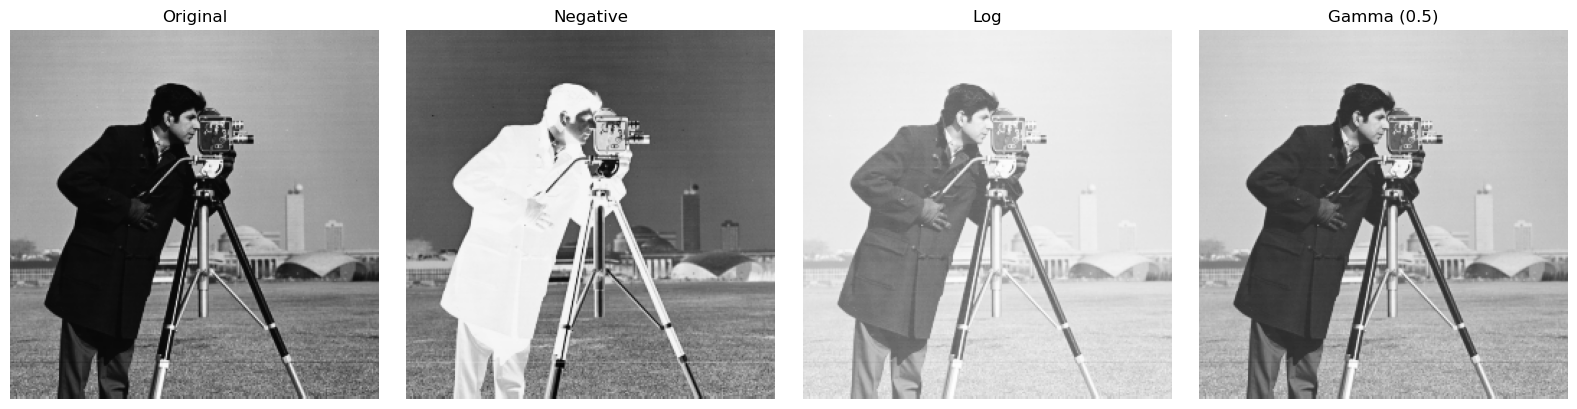

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

images = [
    img,
    negative_pil,
    log_transformed_img,
    gamma_img
]

titles = [
    'Original',
    'Negative',
    'Log',
    f'Gamma ({gamma})'
]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()